## Medidas de Concentración – Curva de Lorenz y Coeficiente de Gini

En esta sección se analiza si los casos de violencia reportados (ponderados por su respectivo factor de expansión) se concentran en pocas entidades federativas o si se distribuyen de forma más homogénea en el territorio nacional. 

Para ello, se reutilizan herramientas de la economía (tradicionalmente empleadas para medir la desigualdad en el ingreso):
1. **Curva de Lorenz:** Representación gráfica donde el eje $X$ acumulado representa el porcentaje de entidades federativas y el eje $Y$ representa el porcentaje acumulado de casos de violencia.
2. **Coeficiente de Gini ($G$):** Mide el área entre la línea de equidistribución perfecta y la curva de Lorenz observada. 
   * $G = 0$: Reparto perfectamente homogéneo (misma proporción de casos en cada entidad).
   * $G \to 1$: Concentración máxima (casi la totalidad de los casos se concentran en muy pocas entidades).

Coeficiente de Gini para nom_entidad: 0.4180
Área bajo la curva de Lorenz: 0.2910
shape: (32, 4)
┌─────────────────────────────────┬─────────────────┬─────────────┬─────────────┐
│ nom_entidad                     ┆ total_violencia ┆ p_entidades ┆ p_violencia │
│ ---                             ┆ ---             ┆ ---         ┆ ---         │
│ str                             ┆ u32             ┆ f64         ┆ f64         │
╞═════════════════════════════════╪═════════════════╪═════════════╪═════════════╡
│ BAJA CALIFORNIA SUR             ┆ 43367           ┆ 0.03125     ┆ 0.004945    │
│ CAMPECHE                        ┆ 55801           ┆ 0.0625      ┆ 0.011308    │
│ COLIMA                          ┆ 56245           ┆ 0.09375     ┆ 0.017722    │
│ NAYARIT                         ┆ 89232           ┆ 0.125       ┆ 0.027897    │
│ ZACATECAS                       ┆ 90345           ┆ 0.15625     ┆ 0.038199    │
│ …                               ┆ …               ┆ …           ┆ …           │
│

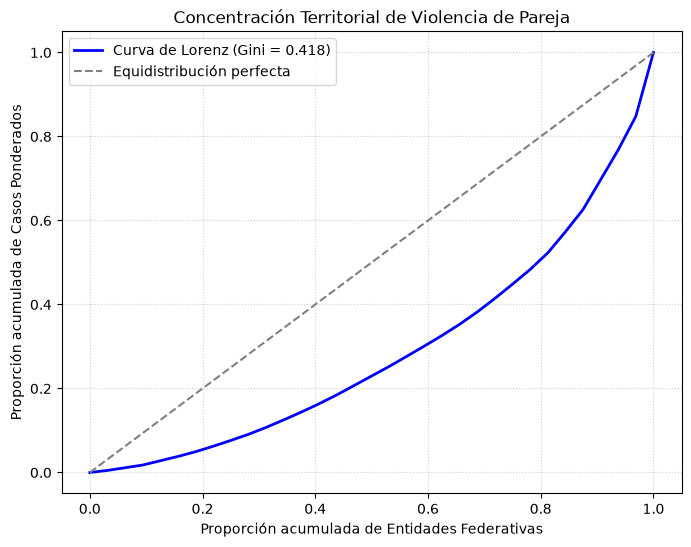

Polars 1.44.2; registros: 105,715


In [2]:
from pathlib import Path
import sys

PROYECTO = Path.cwd().resolve()
if PROYECTO.name == 'notebooks':
    PROYECTO = PROYECTO.parent
if str(PROYECTO) not in sys.path:
    sys.path.insert(0, str(PROYECTO))

import polars as pl
import polars.selectors as cs
from src.analysis.medidas_concentracion import (
    cargar_datos,calcular_indices_gini, COLUM_ENTIDAD

)

df = cargar_datos()
calcular_indices_gini(df,COLUM_ENTIDAD)
print(f'Polars {pl.__version__}; registros: {df.height:,}')

### Interpretación de resultados

Al analizar los datos de violencia por entidad federativa (`nom_entidad`) utilizando el factor de expansión, obtuvimos los siguientes valores:

* **Coeficiente de Gini:** $0.4180$
* **Área bajo la curva de Lorenz:** $0.2910$ *(Nota: el Gini se calcula exactamente como $1 - 2 \times \text{Área}$, lo que comprueba que las cuentas salieron bien: $1 - 2(0.2910) = 0.4180$)*.

#### ¿Qué nos dice esto en la práctica?

1. **Concentración moderada-alta:** Un Gini de $0.4180$ nos indica que los casos de violencia **no están repartidos de forma pareja** por todo el país. No estamos ante una situación donde todos los estados tengan la misma cantidad de casos (lo que daría un Gini de 0), pero tampoco se concentra todo en un solo estado (Gini de 1). 
2. **Existen "focos rojos":** Este número significa que un grupo reducido de entidades federativas acumula una buena parte de los casos reportados, mientras que en la mayoría de los estados la incidencia es considerablemente más baja.
3. **Lectura de la Curva de Lorenz:** El área bajo la curva ($0.2910$) representa gráficamente qué tan alejada está nuestra realidad de la línea de igualdad perfecta (la diagonal de 45 grados). Como la curva se arquea de manera notable, confirma visualmente que hay un desbalance territorial importante que vale la pena tener en cuenta para enfocar apoyos o estrategias de seguridad.